# Alignment Integration

Temporal alignment between source speech timing and target-language TTS audio.
This is the hard problem: a 3-second English phrase might take 5 seconds in Spanish.

Covers segment metrics, fallback policy, and global timeline optimization.

## Setup

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path.cwd() / "images"
IMAGES_DIR.mkdir(exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"IMAGES_DIR:   {IMAGES_DIR}")

PROJECT_ROOT: /Users/bkim/college/ai/foreign-whispers
IMAGES_DIR:   /Users/bkim/college/ai/foreign-whispers/notebooks/alignment_integration/images


## Load Cached Transcripts

Load from `pipeline_data` (no API call needed).

In [11]:
en_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
es_dir = PROJECT_ROOT / "pipeline_data" / "api" / "translations" / "argos"

en_files = sorted(en_dir.glob("*.json"))
es_files = sorted(es_dir.glob("*.json"))

assert en_files, f"No EN transcripts found in {en_dir}"
assert es_files, f"No ES translations found in {es_dir}"

en_path = en_files[1]
es_path = es_files[1]

with open(en_path) as f:
    en_transcript = json.load(f)
with open(es_path) as f:
    es_transcript = json.load(f)

print(f"EN transcript: {en_path.name}  ({len(en_transcript.get('segments', []))} segments)")
print(f"ES transcript: {es_path.name}  ({len(es_transcript.get('segments', []))} segments)")

EN transcript: Strait of Hormuz disruption threatens to shake global economy.json  (98 segments)
ES transcript: Strait of Hormuz disruption threatens to shake global economy.json  (98 segments)


## Segment Timing Metrics

Compute predicted stretch factor and overflow for each segment.

The syllable-based duration heuristic estimates TTS output length at ~4.5 syllables/second
for Romance languages (~15 chars/s). For each segment we compare the predicted TTS duration
against the source-language time window to get `predicted_stretch` (1.0 = perfect fit,
1.3 = 30% too long).

**Notice what happens:** many segments have stretch factors well above 1.0. The translator
doesn't know about the timing budget — it just rewrites text without considering how long
it takes to speak. This is the core problem you'll address in the tasks below.

In [12]:
from foreign_whispers import (
    AlignAction, AlignedSegment, SegmentMetrics,
    compute_segment_metrics, decide_action,
)

all_metrics = compute_segment_metrics(en_transcript, es_transcript)
bad = [m for m in all_metrics if m.predicted_stretch > 1.5]

print(f"Total segments : {len(all_metrics)}")
print(f"Stretch > 1.5x : {len(bad)}  ({100*len(bad)/max(len(all_metrics),1):.0f}%)")
print("\nWorst 5:")
for m in sorted(bad, key=lambda x: -x.predicted_stretch)[:5]:
    print(f"  seg {m.index:3d}  stretch={m.predicted_stretch:.2f}x  overflow={m.overflow_s:.1f}s")
    print(f"    EN: {m.source_text[:55]}")
    print(f"    ES: {m.translated_text[:55]}")

Total segments : 98
Stretch > 1.5x : 14  (14%)

Worst 5:
  seg  93  stretch=2.18x  overflow=2.3s
    EN: But is that what we are witnessing right now?
    ES: ¿Pero eso es lo que estamos presenciando ahora mismo?
  seg  88  stretch=1.96x  overflow=1.0s
    EN: Do you still stand by that?
    ES: ¿Aún estás de acuerdo?
  seg  16  stretch=1.93x  overflow=4.4s
    EN: For most Gulf states, the only way for their oil to rea
    ES: Para la mayoría de los estados del Golfo, la única mane
  seg  66  stretch=1.89x  overflow=3.7s
    EN: India had been under significant pressure from the U.S.
    ES: India había estado bajo una presión significativa de Es
  seg  40  stretch=1.84x  overflow=4.0s
    EN: Now everybody wants his oil and Yakhrismas came early f
    ES: Ahora todo el mundo quiere su aceite y Yakhrismas llegó


## Visualize Stretch Distribution

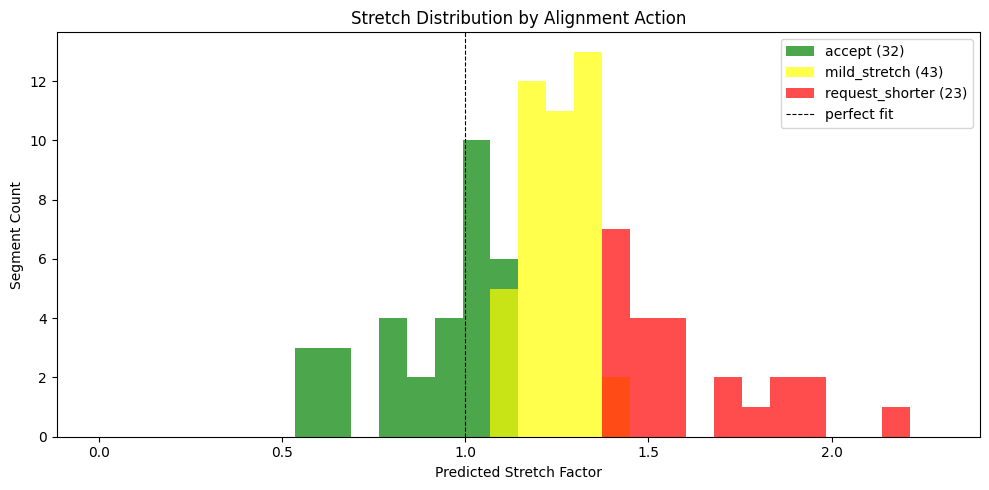

Saved to /Users/bkim/college/ai/foreign-whispers/notebooks/alignment_integration/images/stretch_distribution.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

stretches = [m.predicted_stretch for m in all_metrics]
actions = [decide_action(m) for m in all_metrics]

color_map = {
    AlignAction.ACCEPT: "green",
    AlignAction.MILD_STRETCH: "yellow",
    AlignAction.GAP_SHIFT: "orange",
    AlignAction.REQUEST_SHORTER: "red",
    AlignAction.FAIL: "darkred",
}
colors = [color_map[a] for a in actions]

fig, ax = plt.subplots(figsize=(10, 5))

# Group by action for legend
for action in AlignAction:
    vals = [s for s, a in zip(stretches, actions) if a == action]
    if vals:
        ax.hist(vals, bins=30, alpha=0.7, color=color_map[action],
                label=f"{action.value} ({len(vals)})", range=(0, max(stretches) * 1.05))

ax.axvline(x=1.0, color="black", linestyle="--", linewidth=0.8, label="perfect fit")
ax.set_xlabel("Predicted Stretch Factor")
ax.set_ylabel("Segment Count")
ax.set_title("Stretch Distribution by Alignment Action")
ax.legend()
fig.tight_layout()
fig.savefig(IMAGES_DIR / "stretch_distribution.png", dpi=150)
plt.show()
print(f"Saved to {IMAGES_DIR / 'stretch_distribution.png'}")

---

## Task 1: Improve TTS Duration Prediction

The stretch factors above rely on a crude heuristic: ~15 characters/second for Spanish. Look at the worst segments — the heuristic is often wrong because character count ignores syllable structure, pauses, and speaking rate.

**Goal:** Replace the heuristic with a better duration predictor and measure whether it reduces alignment errors.

**Approach:**
1. Collect ground-truth durations by running TTS on a sample of segments and measuring actual WAV duration
2. Compare predictors: character count, syllable count (use a Spanish syllabifier), and a simple regression model trained on (text features → actual TTS duration)
3. Plug your predictor into `compute_segment_metrics` by modifying the `predicted_tts_duration_s` calculation in `foreign_whispers/alignment.py`

**File to modify:** `foreign_whispers/alignment.py` — the `_estimate_duration` helper

**Evaluation:**
- Mean absolute duration error (predicted vs actual TTS output)
- Calibration: does the predictor work equally well for short and long utterances?
- Downstream: does the improved predictor change the action distribution (fewer `REQUEST_SHORTER` or `FAIL`)? Re-run the policy histogram below to check.

In [14]:
# Task 1: Baseline — measure how wrong the current heuristic is
# Compare predicted duration (chars/15) against actual TTS WAV durations

tts_root = PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox"
align_files = sorted(tts_root.rglob("*.align.json"))

if align_files:
    report = json.loads(align_files[0].read_text())
    segments = report.get("segments", [])

    errors = []
    for seg in segments:
        predicted = seg["target_sec"]  # source window duration
        actual = seg.get("raw_duration_s", 0)
        if actual > 0:
            errors.append(abs(predicted - actual))

    if errors:
        print(f"Segments with TTS ground truth: {len(errors)}")
        print(f"Mean absolute error:  {sum(errors)/len(errors):.2f}s")
        print(f"Max error:            {max(errors):.2f}s")
        print(f"\nThis is the baseline to beat with a better predictor.")
        print(f"Modify _estimate_duration() in foreign_whispers/alignment.py")
    else:
        print("No raw_duration_s data — run the TTS pipeline first (tts_integration notebook)")
else:
    print("No alignment reports found — run the TTS pipeline first")

Segments with TTS ground truth: 20
Mean absolute error:  1.85s
Max error:            4.72s

This is the baseline to beat with a better predictor.
Modify _estimate_duration() in foreign_whispers/alignment.py


## Alignment Fallback Policy

| Stretch Factor | Action            | Description                                |
|----------------|-------------------|--------------------------------------------|
| <= 1.1         | ACCEPT            | Fits naturally, no change needed           |
| 1.1 - 1.4     | MILD_STRETCH      | Apply pyrubberband time-stretch            |
| 1.4 - 1.8     | GAP_SHIFT         | Borrow from adjacent silence gap           |
| 1.8 - 2.5     | REQUEST_SHORTER   | Request a shorter translation              |
| > 2.5         | FAIL              | Unfixable, fall back to silence            |

In [15]:
action_counts = {a: 0 for a in AlignAction}
for m in all_metrics:
    action_counts[decide_action(m)] += 1

print("Policy distribution:")
for action, count in action_counts.items():
    bar = "\u2588" * count
    print(f"  {action.value:<20} {count:3d}  {bar}")

Policy distribution:
  accept                32  ████████████████████████████████
  mild_stretch          43  ███████████████████████████████████████████
  gap_shift              0  
  request_shorter       23  ███████████████████████
  fail                   0  


---

## Task 2: Duration-Aware Translation Re-ranking

Look at the histogram above. Every segment tagged `REQUEST_SHORTER` or `FAIL` is a segment where the Spanish translation is too long to speak in the available time window. The translator doesn't know about duration — it just rewrites text.

**Goal:** For segments that exceed the timing budget, generate shorter translation candidates and pick the one that best fits the source window while preserving meaning.

**Approach:**
1. Filter `all_metrics` for segments where `decide_action(m)` returns `REQUEST_SHORTER`
2. For each, generate 2–3 shorter Spanish alternatives (options: rule-based truncation, LLM candidate generation, or back-translation filtering)
3. Score candidates by: `(predicted_duration - target_duration)² + λ * semantic_distance`
4. Implement this in `foreign_whispers/reranking.py` — the `get_shorter_translations()` stub

**File to modify:** `foreign_whispers/reranking.py`

**Evaluation:**
- How many `REQUEST_SHORTER` segments can you bring down to `MILD_STRETCH` or `ACCEPT`?
- Semantic preservation: compare original and shortened translations using embedding cosine similarity
- Re-run the policy histogram above with your improved translations to measure the shift

In [16]:
# Task 2: Identify the segments that need shorter translations
# These are your targets for re-ranking

over_budget = [m for m in all_metrics if decide_action(m) in (AlignAction.REQUEST_SHORTER, AlignAction.FAIL)]

print(f"Segments needing shorter translations: {len(over_budget)}")
print(f"\nExamples (worst 3):")
for m in sorted(over_budget, key=lambda x: -x.predicted_stretch)[:3]:
    source_dur = m.source_duration_s
    predicted_tts = m.predicted_tts_s
    print(f"\n  seg {m.index}  source_window={source_dur:.1f}s  predicted_tts={predicted_tts:.1f}s  stretch={m.predicted_stretch:.2f}x")
    print(f"    EN: {m.source_text[:70]}")
    print(f"    ES: {m.translated_text[:70]}")
    print(f"    Target: fit TTS into {source_dur:.1f}s → need ~{int(source_dur * 15)} chars or fewer")

Segments needing shorter translations: 23

Examples (worst 3):

  seg 93  source_window=1.9s  predicted_tts=4.2s  stretch=2.18x
    EN: But is that what we are witnessing right now?
    ES: ¿Pero eso es lo que estamos presenciando ahora mismo?
    Target: fit TTS into 1.9s → need ~28 chars or fewer

  seg 88  source_window=1.0s  predicted_tts=2.0s  stretch=1.96x
    EN: Do you still stand by that?
    ES: ¿Aún estás de acuerdo?
    Target: fit TTS into 1.0s → need ~15 chars or fewer

  seg 16  source_window=4.8s  predicted_tts=9.2s  stretch=1.93x
    EN: For most Gulf states, the only way for their oil to reach the global m
    ES: Para la mayoría de los estados del Golfo, la única manera para que su 
    Target: fit TTS into 4.8s → need ~71 chars or fewer


In [17]:
# Uses `actions` from the stretch-distribution cell (same order as `all_metrics`).

from foreign_whispers.alignment import _estimate_duration
from foreign_whispers.reranking import get_shorter_translations
from sentence_transformers import SentenceTransformer

es_segs = es_transcript.get("segments", [])

# One list for downstream plotting: predicted TTS before/after (seconds) per over-budget segment
changed_segments = []

SEMANTIC_LAMBDA = 0.5

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

for m in sorted(over_budget, key=lambda x: -x.predicted_stretch):
    prev_t = es_segs[m.index - 1]["text"] if m.index > 0 else ""
    next_t = es_segs[m.index + 1]["text"] if m.index < len(es_segs) - 1 else ""
    candidates = get_shorter_translations(
        source_text=m.source_text,
        baseline_es=m.translated_text,
        target_duration_s=m.source_duration_s,
        context_prev=prev_t,
        context_next=next_t,
    )

    row = {
        "index": m.index,
        "window_s": m.source_duration_s,
        "pred_tts_before": m.predicted_tts_s,
        "pred_tts_after": None,
    }

    if not candidates:
        changed_segments.append(row)
        print(f"seg {m.index}: no candidates  pred_tts={m.predicted_tts_s:.2f}s  stretch={m.predicted_stretch:.2f}x")
        continue

    baseline_emb = model.encode(m.translated_text, convert_to_numpy=True, normalize_embeddings=True)

    for i in range(len(candidates)):
        predicted_duration = _estimate_duration(candidates[i].text)
        candidate_emb = model.encode(candidates[i].text, convert_to_numpy=True, normalize_embeddings=True)

        cosine_similarity = np.dot(baseline_emb, candidate_emb.T)
        semantic_distance = 1 - cosine_similarity

        score = (predicted_duration - m.source_duration_s) ** 2 + (SEMANTIC_LAMBDA * semantic_distance)

        candidates[i].predicted_duration = predicted_duration
        candidates[i].score = score

    best = min(candidates, key=lambda c: c.score)
    row["pred_tts_after"] = best.predicted_duration
    changed_segments.append(row)

    new_stretch = best.predicted_duration / m.source_duration_s if m.source_duration_s > 0 else 1.0
    print(
        f"seg {m.index}  pred_tts {m.predicted_tts_s:.2f}s → {best.predicted_duration:.2f}s  "
        f"stretch {m.predicted_stretch:.2f}x → {new_stretch:.2f}x"
    )
    print(f"  ES now: {best.text[:90]}...")

n_ok = sum(
    1
    for c in changed_segments
    if c["pred_tts_after"] is not None and c["pred_tts_after"] / c["window_s"] <= 1.4
)
print(f"\nStretch ≤ 1.4x after re-rank: {n_ok} / {len(changed_segments)}")


/Users/bkim/college/ai/foreign-whispers/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 50362.10it/s]


seg 93  pred_tts 4.19s → 2.58s  stretch 2.18x → 1.35x
  ES now: ¿Es eso lo que estamos viendo?...
seg 88  pred_tts 1.96s → 1.53s  stretch 1.96x → 1.53x
  ES now: ¿Sigues con eso?...
seg 16  pred_tts 9.16s → 4.64s  stretch 1.93x → 0.97x
  ES now: Para la mayoría de los países del Golfo, la única vía es…...
seg 66  pred_tts 7.77s → 4.56s  stretch 1.89x → 1.11x
  ES now: India presiona a EEUU para dejar de comprar petróleo ruso....


Error calling Gemini API: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 51.890312316s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'model': 'gemini-2.5-flash-lite',

seg 40  pred_tts 8.77s → 3.56s  stretch 1.84x → 0.75x
  ES now: Putin recibe aceite de Yakhrismas, ¿beneficio?...
seg 28  pred_tts 7.10s → 4.25s  stretch 1.79x → 1.07x
  ES now: No, Arabia Saudí no puede exportar todos sus barriles....
seg 53  pred_tts 7.47s → 4.32s  stretch 1.71x → 0.99x
  ES now: Pensar que eso es inestable a largo plazo es terrible....
seg 82  pred_tts 1.70s → 1.70s  stretch 1.70x → 1.70x
  ES now: Dámelo directamente....
seg 22  pred_tts 5.86s → 2.95s  stretch 1.59x → 0.80x
  ES now: Preocupado por el estrecho de Ormuz....


Error calling Gemini API: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 38.110789026s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'g

seg 8  pred_tts 7.91s → 2.70s  stretch 1.57x → 0.54x
  ES now: Barcos: 1/5 del petróleo mundial....


Error calling Gemini API: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 33.882187651s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'model': 'gemini-2.5-flash-lite',

seg 10  pred_tts 7.05s → 3.31s  stretch 1.55x → 0.73x
  ES now: Irán: tráfico casi detenido, mundo siente....
seg 20  pred_tts 6.79s → 3.25s  stretch 1.54x → 0.74x
  ES now: Arabia Saudita, ganador con su oleoducto....
seg 4  pred_tts 6.69s → 3.51s  stretch 1.52x → 0.80x
  ES now: Realidad: lo más largo y con mayor impacto....
seg 72  pred_tts 1.52s → 1.52s  stretch 1.52x → 1.52x
  ES now: grandes reservas....
seg 26  pred_tts 7.67s → 5.87s  stretch 1.48x → 1.13x
  ES now: Mientras que países como Irak, Kuwait y Qatar no lo pueden, por lo tanto......


Error calling Gemini API: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 18.585135785s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'g

seg 34  pred_tts 7.85s → 3.63s  stretch 1.45x → 0.67x
  ES now: Bob McNally: asesor de Bush en Irak, ahora......
seg 73  pred_tts 4.39s → 4.39s  stretch 1.44x → 1.44x
  ES now: Por lo tanto, para la India, esta es una crisis aguda....
seg 27  pred_tts 2.58s → 2.58s  stretch 1.43x → 1.43x
  ES now: tener que cerrar la producción....
seg 61  pred_tts 7.29s → 6.68s  stretch 1.42x → 1.30x
  ES now: pasando por el estrecho sin ser detectado, y enviando la mayor parte del crudo a bordo...
seg 85  pred_tts 6.00s → 4.82s  stretch 1.41x → 1.14x
  ES now: Será un conflicto más largo y costoso de lo que se esperaba....
seg 6  pred_tts 7.43s → 6.74s  stretch 1.41x → 1.28x
  ES now: Esta semana, en 60 minutos, informamos en la calle de Hormuz que estrecho canal en Irán...
seg 13  pred_tts 9.20s → 7.46s  stretch 1.40x → 1.14x
  ES now: Entrevistamos a Matt Smith, analista de Kepler, experto en el mercado petrolero y comercio...
seg 30  pred_tts 5.49s → 3.08s  stretch 1.40x → 0.79x
  ES now: ¿Qué ocu

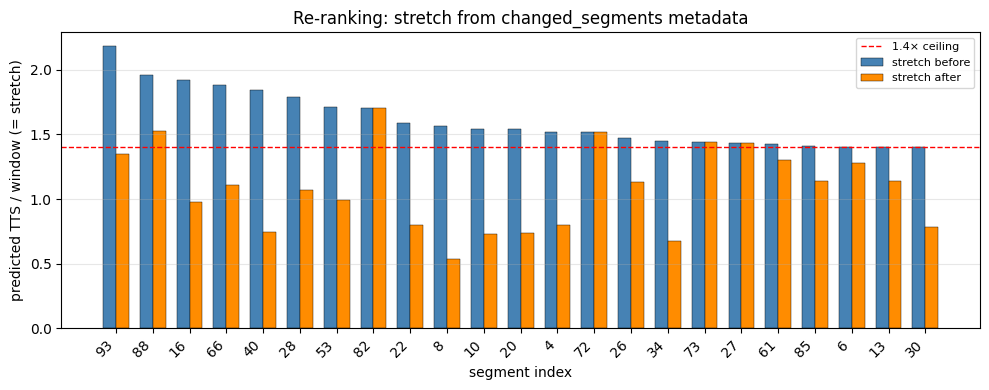

In [18]:
import matplotlib.pyplot as plt
import numpy as np

if "changed_segments" not in globals():
    raise RuntimeError("Run the re-ranking cell above first.")

chs = changed_segments
idx = np.array([c["index"] for c in chs], dtype=int)
before = np.array([c["pred_tts_before"] / c["window_s"] for c in chs], dtype=float)
after = np.array(
    [
        (c["pred_tts_after"] / c["window_s"]) if c["pred_tts_after"] is not None else np.nan
        for c in chs
    ],
    dtype=float,
)
x = np.arange(len(chs))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w / 2, before, w, label="stretch before", color="steelblue", edgecolor="k", linewidth=0.3)
ax.bar(x + w / 2, after, w, label="stretch after", color="darkorange", edgecolor="k", linewidth=0.3)
ax.axhline(1.4, color="red", ls="--", lw=1, label="1.4× ceiling")
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in idx], rotation=45, ha="right")
ax.set_xlabel("segment index")
ax.set_ylabel("predicted TTS / window (= stretch)")
ax.set_title("Re-ranking: stretch from changed_segments metadata")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Global Timeline Alignment

Optimizer that shifts segments into available silence gaps instead of forcing local stretches.
Uses a greedy left-to-right pass tracking cumulative drift from gap shifts.

In [19]:
from pathlib import Path
from foreign_whispers.vad import detect_speech_activity

# Same clip as your EN/ES JSON — path to source video (mp4/wav as Silero can read)
video_path = PROJECT_ROOT / "pipeline_data" / "api" / "videos" / f"{en_path.stem}.mp4"
silence_regions = detect_speech_activity(str(video_path))

In [20]:
from foreign_whispers import global_align_dp
from foreign_whispers import global_align

# silence_regions = []  # Would come from VAD if silero-vad installed
silence_regions = detect_speech_activity(str(video_path))
aligned_segments = global_align_dp(all_metrics, silence_regions)

shifts = [s for s in aligned_segments if s.action == AlignAction.GAP_SHIFT]
stretches = [s for s in aligned_segments if s.action == AlignAction.MILD_STRETCH]
drift = aligned_segments[-1].scheduled_end - aligned_segments[-1].original_end if aligned_segments else 0.0

print(f"Gap shifts     : {len(shifts)}")
print(f"Mild stretches : {len(stretches)}")
print(f"Total drift    : {drift:.2f}s")

Gap shifts     : 0
Mild stretches : 43
Total drift    : 0.00s


## Visualize Alignment Timeline

Plot original vs scheduled timing for each segment.

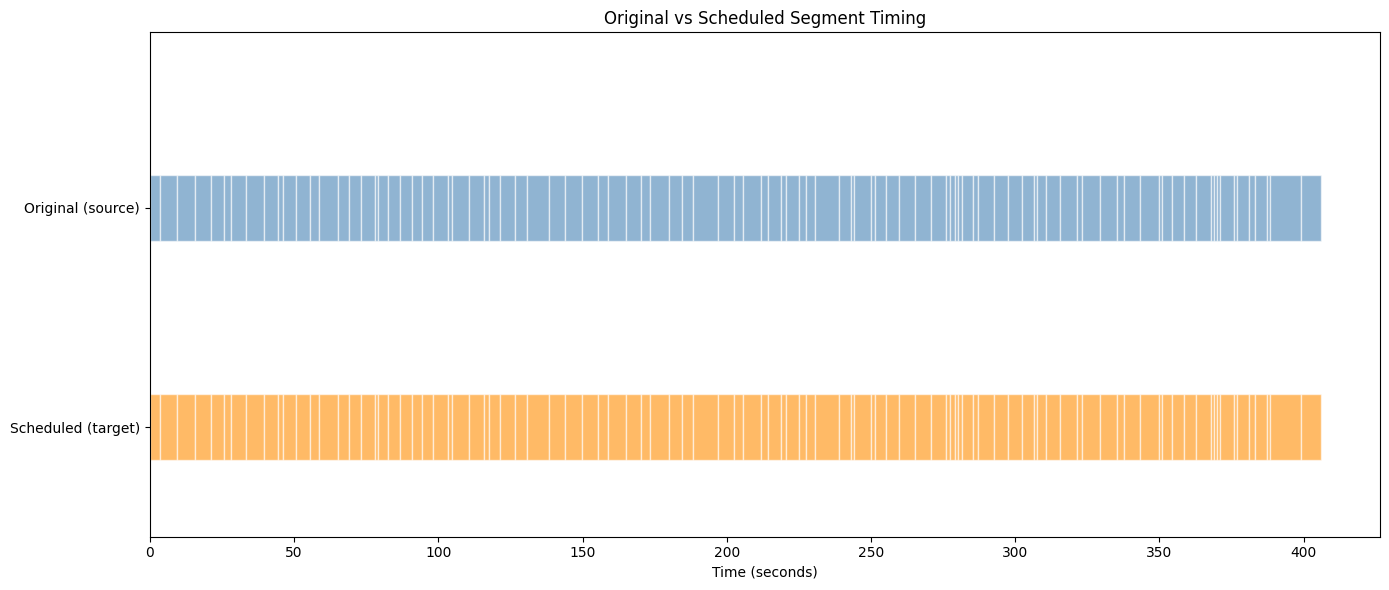

Saved to /Users/bkim/college/ai/foreign-whispers/notebooks/alignment_integration/images/alignment_timeline.png


In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

y_original = 1
y_scheduled = 0

for seg in aligned_segments:
    # Original timing (blue)
    ax.barh(y_original, seg.original_end - seg.original_start,
            left=seg.original_start, height=0.3, color="steelblue", alpha=0.6,
            edgecolor="white")
    # Scheduled timing (orange)
    ax.barh(y_scheduled, seg.scheduled_end - seg.scheduled_start,
            left=seg.scheduled_start, height=0.3, color="darkorange", alpha=0.6,
            edgecolor="white")

ax.set_yticks([y_scheduled, y_original])
ax.set_yticklabels(["Scheduled (target)", "Original (source)"])
ax.set_xlabel("Time (seconds)")
ax.set_title("Original vs Scheduled Segment Timing")
ax.set_ylim(-0.5, 1.8)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "alignment_timeline.png", dpi=150)
plt.show()

print(f"Saved to {IMAGES_DIR / 'alignment_timeline.png'}")

---

## Task 3: Beat the Greedy Optimizer

The timeline above was produced by `global_align()` — a greedy left-to-right pass. It makes locally optimal decisions but can't look ahead. A segment that borrows silence early may starve a later segment that needed it more.

**Goal:** Implement a better global optimizer and compare it against the greedy baseline.

**Approach:**
1. Record the greedy baseline metrics: total drift, number of gap shifts, number of segments still in `REQUEST_SHORTER` or `FAIL` after alignment
2. Implement one of these alternatives in a new function (e.g. `global_align_dp` in `foreign_whispers/alignment.py`):
   - **Dynamic programming:** minimize total stretch penalty over all segments, subject to non-overlapping constraints
   - **Integer linear programming:** formulate as an optimization problem with scipy or PuLP — decision variables are per-segment time allocations, constraints enforce non-overlap and silence budgets
   - **Beam search:** explore multiple scheduling trajectories, prune by cumulative drift
3. Compare your optimizer against the greedy baseline on the same clip

**File to modify:** `foreign_whispers/alignment.py` — add your optimizer alongside `global_align`

**Evaluation:**
- Total cumulative drift (lower is better)
- Number of segments requiring severe stretch (>1.4x)
- Number of segments that overlap in the scheduled timeline
- Re-plot the timeline visualization above with your optimizer's output

In [22]:
# Task 3: Record the greedy baseline to compare against your optimizer

from foreign_whispers import clip_evaluation_report

greedy_report = clip_evaluation_report(all_metrics, aligned_segments)

print("=== Greedy Baseline ===")
for key, val in greedy_report.items():
    print(f"  {key}: {val}")

print(f"\nYour optimizer should improve on these numbers.")
print(f"Add global_align_dp() to foreign_whispers/alignment.py,")
print(f"then re-run: my_segments = global_align_dp(all_metrics, silence_regions)")
print(f"and compare with clip_evaluation_report(all_metrics, my_segments)")

=== Greedy Baseline ===
  mean_abs_duration_error_s: 1.169
  pct_severe_stretch: 0.0
  n_gap_shifts: 0
  n_translation_retries: 23
  total_cumulative_drift_s: 0.0

Your optimizer should improve on these numbers.
Add global_align_dp() to foreign_whispers/alignment.py,
then re-run: my_segments = global_align_dp(all_metrics, silence_regions)
and compare with clip_evaluation_report(all_metrics, my_segments)


---

## Task 4: Build a Dubbing Quality Scorecard

The `clip_evaluation_report()` above gives you five numbers. But dubbing quality is multi-dimensional — timing accuracy is necessary but not sufficient. A clip with perfect timing but garbled speech is still a failure.

**Goal:** Design and implement a richer evaluation framework that scores clips across multiple dimensions.

**Dimensions to consider:**
- **Timing accuracy:** mean absolute duration error, percentage of severe stretches, cumulative drift (you already have these)
- **Intelligibility:** can you use a speech-to-text round-trip? TTS the Spanish, then STT it back — compare against the translation. Word error rate of the round-trip measures intelligibility.
- **Semantic fidelity:** how much meaning was lost? Compare source English and back-translated English using embedding cosine similarity
- **Naturalness:** speaking rate variance across segments — is it consistent or does it jump between fast and slow?

**Approach:**
1. Implement `dubbing_scorecard(metrics, aligned_segments, align_report)` in `foreign_whispers/evaluation.py`
2. Return a dict with scores per dimension, each normalized to [0, 1]
3. Add a summary visualization — a radar chart or bar chart comparing baseline vs aligned

**File to modify:** `foreign_whispers/evaluation.py`

**Evaluation:**
- Does your scorecard distinguish between good and bad clips?
- Do the dimensions correlate with each other, or do they capture independent quality aspects?
- Run on multiple videos from `video_registry.yml` and compare

In [36]:
from foreign_whispers.evaluation import dubbing_scorecard

# TTS sidecar written next to the WAV (see api/src/services/tts_engine.py::_write_align_report)
_align_paths = sorted(
    (PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox").rglob(
        f"{en_path.stem}.align.json"
    )
)
if not _align_paths:
    _align_paths = sorted(
        (PROJECT_ROOT / "pipeline_data" / "api" / "tts_audio" / "chatterbox").rglob(
            "*.align.json"
        )
    )
if not _align_paths:
    raise FileNotFoundError(
        "No .align.json under pipeline_data/api/tts_audio/chatterbox — run the TTS pipeline first."
    )
align_report = json.loads(_align_paths[0].read_text())
print(f"Using align sidecar: {_align_paths[0].relative_to(PROJECT_ROOT)}\n")

print(dubbing_scorecard(all_metrics, aligned_segments, align_report))

Using align sidecar: pipeline_data/api/tts_audio/chatterbox/c-fb1074a/Strait of Hormuz disruption threatens to shake global economy.align.json



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6986.12it/s]


{'clip_evaluation_report': {'mean_abs_duration_error_s': 1.169, 'pct_severe_stretch': 0.0, 'n_gap_shifts': 0, 'n_translation_retries': 23, 'total_cumulative_drift_s': 0.0}, 'semantic_back_translations_en': [{'index': 0, 'cosine_similarity': 0.9705116748809814, 'original_text': '60 minutes over time.', 'translated_text': '60 minutos con el tiempo.', 'back_translation': '60 minutes in time.'}, {'index': 1, 'cosine_similarity': 0.9704523086547852, 'original_text': "What's the worst case scenario that you're worried about?", 'translated_text': '¿Cuál es el peor escenario que te preocupa?', 'back_translation': "What's the worst scenario you're worried about?"}, {'index': 2, 'cosine_similarity': 0.8683993816375732, 'original_text': 'Is that it is closed for weeks and weeks and weeks here and you start to see the global', 'translated_text': 'Es que está cerrado durante semanas y semanas y semanas aquí y empiezas a ver el mundo', 'back_translation': "It's closed for weeks and weeks and weeks h

---

## Summary

Alignment is pure Python, no GPU required. All the timing analysis, policy decisions,
and global scheduling run on CPU with zero external dependencies beyond stdlib.

### Task overview

| Task | What you build | File to modify | Evaluation |
|------|---------------|----------------|------------|
| 1. Duration Prediction | Better TTS duration estimator | `alignment.py` — `_estimate_duration` | Mean absolute error vs ground truth |
| 2. Translation Re-ranking | Shorter candidates that fit the timing budget | `reranking.py` — `get_shorter_translations` | Segments moved from `REQUEST_SHORTER` to `ACCEPT` |
| 3. Global Optimizer | DP/ILP/search optimizer that beats greedy | `alignment.py` — new `global_align_dp` | Total drift, severe stretch count |
| 4. Quality Scorecard | Multi-dimensional evaluation framework | `evaluation.py` — new `dubbing_scorecard` | Dimension independence, cross-clip consistency |

Each task builds on the analysis you ran above and uses data already in `pipeline_data/`.
Validate your results end-to-end by re-running the TTS and stitch notebooks.

### Cross-notebook connections

- **Speaker-aware alignment** — the `diarization_integration` notebook labels speaker turns.
  Feed that signal into your optimizer to prevent borrowing silence across speaker boundaries.
- **Voice cloning** — the `tts_integration` notebook wires per-speaker voice selection.
  Combined with diarization, different speakers get different voices.
